# End-to-End Biomass Prediction Pipeline with Deep Learning

**Objective:** This notebook integrates exploratory data analysis, advanced feature engineering, and a deep learning model to create a competitive solution for the CSIRO Image2Biomass competition.

The pipeline follows best practices from top Kaggle notebooks and the guidance provided in `furtherinst.md`:
1.  **Advanced EDA:** Deeper analysis of feature correlations and target distributions.
2.  **Feature Engineering:** Combines metadata with deep features from a pretrained CNN (EfficientNet-B0).
3.  **Modeling:** Uses a multi-output regression model with a custom weighted loss function to align with the competition's R² metric.
4.  **Training:** Implements a robust training and validation scheme using `GroupKFold` to prevent data leakage.
5.  **Inference:** Generates predictions on the test set and formats the output for submission.


## 1. Setup, Imports and Configuration


In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

class CFG:
    seed = 42
    model_name = 'efficientnet_b0'
    img_size = 224
    batch_size = 32
    n_epochs = 10
    lr = 1e-3
    n_folds = 5
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

set_seed(CFG.seed)

print(f"Using device: {CFG.device}")


d:\Proyecto CSIRO\Biomass\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


## 2. Data Loading and Advanced EDA

We load the data and pivot it into a wide format, where each row represents a unique image and target variables are in separate columns. This is the correct format for multi-output modeling.


In [2]:
def get_data_dir():
    # Returns the data directory based on the environment (Kaggle or local).
    if Path("/kaggle/input/csiro-biomass").exists():
        return Path("/kaggle/input/csiro-biomass")
    else:
        return Path("data")

DATA_DIR = get_data_dir()
print(f"Data directory: {DATA_DIR}")

train_df_long = pd.read_csv(DATA_DIR / 'train.csv')
test_df_long = pd.read_csv(DATA_DIR / 'test.csv')

def pivot_data(df):
    pivot_df = df.pivot_table(index='image_path', columns='target_name', values='target').reset_index()
    meta_cols = ['image_path', 'Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']
    meta_cols = [col for col in meta_cols if col in df.columns]
    meta_df = df[meta_cols].drop_duplicates(subset=['image_path'])
    final_df = pd.merge(pivot_df, meta_df, on='image_path')
    return final_df

train_df = pivot_data(train_df_long)

print("Pivoted Training Data Shape:", train_df.shape)
display(train_df.head())


Data directory: data
Pivoted Training Data Shape: (357, 11)


,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,Sampling_Date,State,Species,Pre_GSHH_NDVI,Height_Ave_cm
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750,2015/9/4,Tas,Ryegrass_Clover,0.62,4.6667
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000,2015/4/1,NSW,Lucerne,0.55,16.0000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500,2015/9/1,WA,SubcloverDalkeith,0.38,1.0000
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376,2015/5/18,Tas,Ryegrass,0.66,5.0000
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605,2015/9/11,Tas,Ryegrass,0.54,3.5000


### Correlation Analysis


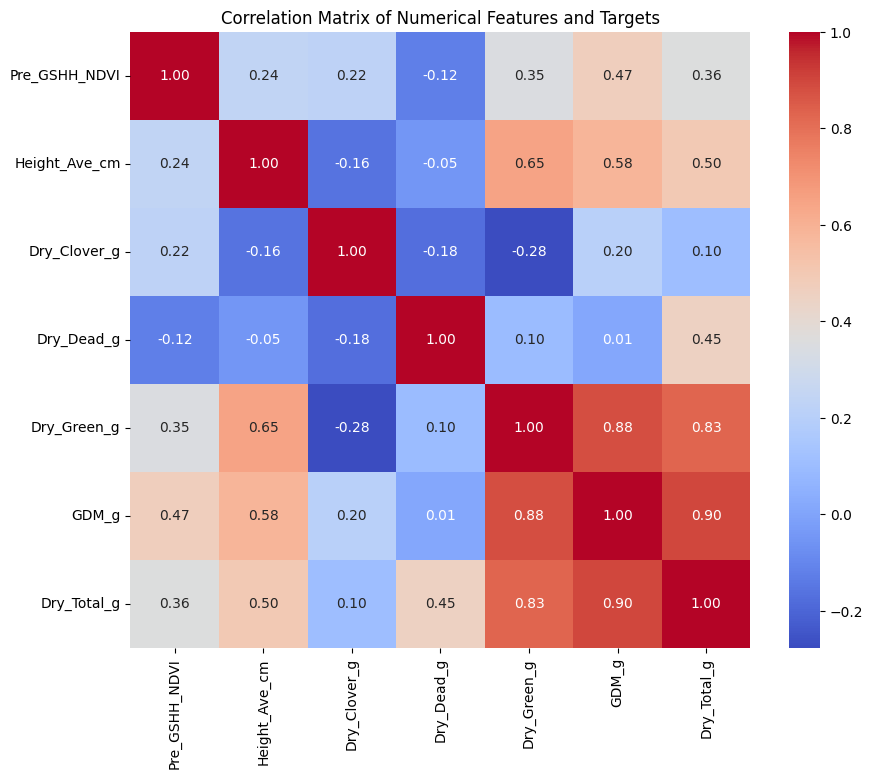

In [3]:
target_cols = ['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'GDM_g', 'Dry_Total_g']
numerical_meta_cols = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

corr_matrix = train_df[numerical_meta_cols + target_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features and Targets')
plt.show()


### PCA and t-SNE Visualization

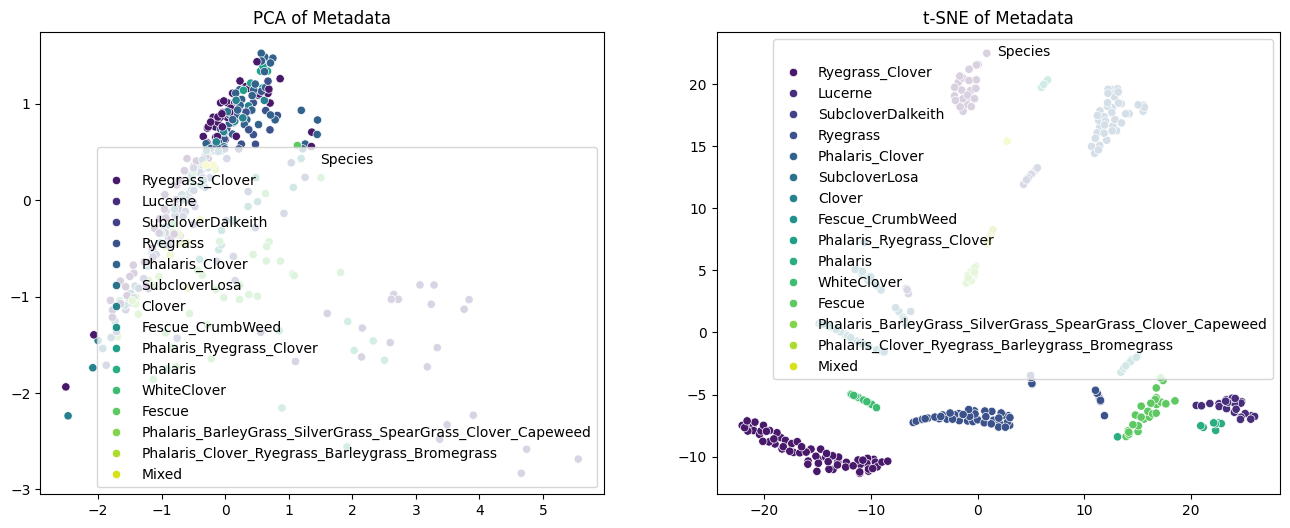

In [4]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

metadata_df = train_df.drop(columns=target_cols + ['image_path', 'Sampling_Date'])
numerical_cols = metadata_df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = metadata_df.select_dtypes(exclude=np.number).columns.tolist()

preprocessor_viz = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

metadata_scaled = preprocessor_viz.fit_transform(metadata_df)

# PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(metadata_scaled.toarray() if hasattr(metadata_scaled, 'toarray') else metadata_scaled)

# t-SNE
tsne = TSNE(n_components=2, perplexity=min(30, len(metadata_df) - 1), random_state=CFG.seed)
tsne_result = tsne.fit_transform(metadata_scaled.toarray() if hasattr(metadata_scaled, 'toarray') else metadata_scaled)

plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=train_df['Species'], palette='viridis')
plt.title('PCA of Metadata')

plt.subplot(1, 2, 2)
sns.scatterplot(x=tsne_result[:, 0], y=tsne_result[:, 1], hue=train_df['Species'], palette='viridis')
plt.title('t-SNE of Metadata')

plt.show()

## 3. Preprocessing, Dataset and DataLoaders


In [5]:
transforms = T.Compose([
    T.Resize((CFG.img_size, CFG.img_size)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

categorical_features = ['State', 'Species']
numerical_features = ['Pre_GSHH_NDVI', 'Height_Ave_cm']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

class BiomassDataset(Dataset):
    def __init__(self, df, metadata_preprocessor, transforms, is_test=False):
        self.df = df
        self.preprocessor = metadata_preprocessor
        self.transforms = transforms
        self.is_test = is_test
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = DATA_DIR / row['image_path']
        image = Image.open(img_path).convert('RGB')
        image = self.transforms(image)
        
        meta_arr = self.preprocessor.transform(
            self.df.iloc[[idx]][numerical_features + categorical_features]
        )
        # OneHotEncoder devuelve sparse por defecto
        if hasattr(meta_arr, 'toarray'):
            meta_arr = meta_arr.toarray()
        meta = torch.tensor(meta_arr.squeeze(), dtype=torch.float32)
        
        if self.is_test:
            return image, meta
        else:
            targets = torch.tensor(row[target_cols].values.astype(np.float32), dtype=torch.float32)
            return image, meta, targets

preprocessor.fit(train_df[numerical_features + categorical_features])
metadata_dim = preprocessor.transform(train_df[numerical_features + categorical_features]).shape[1]
print(f"Dimension of preprocessed metadata: {metadata_dim}")


Dimension of preprocessed metadata: 21


## 4. Model Architecture

We define a model that combines a pretrained CNN for image feature extraction with a multi-layer perceptron (MLP) for metadata. The features are then concatenated and passed to a final regression head.


In [6]:
class BiomassModel(nn.Module):
    def __init__(self, model_name, metadata_dim, n_targets, pretrained=True):
        super().__init__()
        self.image_model = timm.create_model("resnet18", pretrained=False, num_classes=0)
        self.image_model.load_state_dict(
            torch.load("resnet18_pretrained.pth"),
            strict=False  # ✅ <- 
        )
        in_features = self.image_model.num_features
        self.meta_mlp = nn.Sequential(
            nn.Linear(metadata_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64)
        )
        self.head = nn.Linear(in_features + 64, n_targets)

    def forward(self, image, metadata):
        img_features = self.image_model(image)
        meta_features = self.meta_mlp(metadata)
        combined_features = torch.cat([img_features, meta_features], dim=1)
        output = self.head(combined_features)
        return output

model = BiomassModel(
    model_name=CFG.model_name,
    metadata_dim=metadata_dim,
    n_targets=len(target_cols)
)
model.to(CFG.device)
print("Model architecture loaded successfully.")


Model architecture loaded successfully.


## 5. Training and Validation

Implemented GridSearch for getting best hyperparameters.

We implement a standard training loop and use GroupKFold cross-validation to ensure our model generalizes well. The `Sampling_Date` is used to group the data, preventing images from the same day from appearing in both the training and validation sets.


In [8]:
from tqdm import tqdm

def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0
    for image, meta, targets in tqdm(dataloader, desc="Training"):
        image, meta, targets = image.to(CFG.device), meta.to(CFG.device), targets.to(CFG.device)
        optimizer.zero_grad()
        predictions = model(image, meta)
        loss = criterion(predictions, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for image, meta, targets in tqdm(dataloader, desc="Validation"):
            image, meta, targets = image.to(CFG.device), meta.to(CFG.device), targets.to(CFG.device)
            predictions = model(image, meta)
            loss = criterion(predictions, targets)
            total_loss += loss.item()
    return total_loss / len(dataloader)


In [9]:
from sklearn.model_selection import train_test_split
from itertools import product

# ==============================
#  BÚSQUEDA DE HIPERPARÁMETROS
# ==============================

# 1) Subconjunto para acelerar la búsqueda
#    (ajusta frac según tu paciencia/GPU)
train_subset_df = train_df.sample(frac=0.5, random_state=CFG.seed).reset_index(drop=True)

# 2) Split simple train/val dentro de ese subset
hp_train_df, hp_val_df = train_test_split(
    train_subset_df,
    test_size=0.2,
    random_state=CFG.seed
)

hp_train_dataset = BiomassDataset(hp_train_df, preprocessor, transforms)
hp_val_dataset   = BiomassDataset(hp_val_df, preprocessor, transforms)

hp_train_loader = DataLoader(hp_train_dataset, batch_size=CFG.batch_size, shuffle=True)
hp_val_loader   = DataLoader(hp_val_dataset,   batch_size=CFG.batch_size, shuffle=False)

def run_hp_experiment(lr, optimizer_cls, n_epochs_hp=3):
    """Entrena un modelo pequeño con (lr, optimizer_cls) y devuelve val_loss."""
    model = BiomassModel(
        model_name=CFG.model_name,
        metadata_dim=metadata_dim,
        n_targets=len(target_cols)
    ).to(CFG.device)

    optimizer = optimizer_cls(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")

    for epoch in range(n_epochs_hp):
        train_loss = train_one_epoch(model, hp_train_loader, optimizer, criterion)
        val_loss   = validate(model, hp_val_loader, criterion)
        print(f"[HP] lr={lr}, opt={optimizer_cls.__name__}, "
              f"epoch={epoch+1}: train={train_loss:.4f}, val={val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss

    return best_val_loss

# 3) Definir rejilla de hiperparámetros
param_grid = {
    "lr": [1e-4, 1e-3, 1e-2],
    "optimizer": [torch.optim.Adam, torch.optim.SGD],
}

best_score = float("inf")
best_params = None

# 4) Grid search “a mano”
for lr, optimizer_cls in product(param_grid["lr"], param_grid["optimizer"]):
    val_loss = run_hp_experiment(lr, optimizer_cls, n_epochs_hp=3)
    print(f"[HP] Resultado lr={lr}, opt={optimizer_cls.__name__}: val_loss={val_loss:.4f}")

    if val_loss < best_score:
        best_score = val_loss
        best_params = {
            "lr": lr,
            "optimizer_name": optimizer_cls.__name__.lower()   # "adam" o "sgd"
        }

print("\n==============================")
print(f"Mejores hiperparámetros encontrados:")
print(f"  val_loss = {best_score:.4f}")
print(f"  lr       = {best_params['lr']}")
print(f"  optimizer= {best_params['optimizer_name']}")
print("==============================")

# 5) Guardar en CFG para usarlos en el entrenamiento oficial
CFG.lr = best_params["lr"]
CFG.optimizer_name = best_params["optimizer_name"]


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.12it/s]


[HP] lr=0.0001, opt=Adam, epoch=1: train=1395.9090, val=1430.7456


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.15it/s]


[HP] lr=0.0001, opt=Adam, epoch=2: train=1427.9246, val=1426.1707


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.10it/s]


...

[HP] lr=0.01, opt=SGD, epoch=1: train=996.8777, val=873.4538


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.06it/s]


[HP] lr=0.01, opt=SGD, epoch=2: train=481.2445, val=680.6932


Validation: 100%|██████████| 2/2 [00:01<00:00,  1.02it/s]

[HP] lr=0.01, opt=SGD, epoch=3: train=332.3572, val=568.6946
[HP] Resultado lr=0.01, opt=SGD: val_loss=568.6946

Mejores hiperparámetros encontrados:
  val_loss = 568.6946
  lr       = 0.01
  optimizer= sgd


In [10]:
from sklearn.model_selection import KFold

def get_optimizer_from_cfg(model):
    opt_name = getattr(CFG, "optimizer_name", "adam").lower()
    if opt_name == "sgd":
        optimizer_cls = torch.optim.SGD
    else:
        optimizer_cls = torch.optim.Adam
    return optimizer_cls(model.parameters(), lr=CFG.lr)

gkf = GroupKFold(n_splits=CFG.n_folds)
groups = train_df['Sampling_Date']

for fold, (train_idx, val_idx) in enumerate(gkf.split(train_df, groups=groups)):
    print(f"--- Fold {fold+1}/{CFG.n_folds} ---")
    train_fold_df = train_df.iloc[train_idx]
    val_fold_df = train_df.iloc[val_idx]

    train_dataset = BiomassDataset(train_fold_df, preprocessor, transforms)
    val_dataset = BiomassDataset(val_fold_df, preprocessor, transforms)

    train_loader = DataLoader(train_dataset, batch_size=CFG.batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=CFG.batch_size, shuffle=False)

    model = BiomassModel(CFG.model_name, metadata_dim, len(target_cols)).to(CFG.device)
    optimizer = get_optimizer_from_cfg(model)
    criterion = nn.MSELoss()

    for epoch in range(CFG.n_epochs):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = validate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    # For demo purposes, solo un fold
    break


--- Fold 1/5 ---


Validation: 100%|██████████| 3/3 [00:04<00:00,  1.37s/it]


Epoch 1: Train Loss: 771.5156, Val Loss: 346.2796


Validation: 100%|██████████| 3/3 [00:04<00:00,  1.38s/it]


Epoch 2: Train Loss: 482.0966, Val Loss: 364.3514


...

Epoch 8: Train Loss: 158.2841, Val Loss: 195.9325


Validation: 100%|██████████| 3/3 [00:04<00:00,  1.37s/it]


Epoch 9: Train Loss: 112.9241, Val Loss: 182.1743


Validation: 100%|██████████| 3/3 [00:03<00:00,  1.26s/it]

Epoch 10: Train Loss: 101.9893, Val Loss: 222.3775


## 6. Inference and Submission

Finally, we generate predictions on the test set. The test data needs to be preprocessed in the same way as the training data. The final predictions are reshaped back into the long format required for submission.


In [11]:
test_meta_df = test_df_long[['image_path']].drop_duplicates().copy()

# ✅ Imputar columnas faltantes usando moda (para categóricas) o media (para numéricas)
meta_fill_values = {}
for col in ['Sampling_Date', 'State', 'Species', 'Pre_GSHH_NDVI', 'Height_Ave_cm']:
    if col in train_df:
        if train_df[col].dtype == 'object':
            fill_value = train_df[col].mode()[0]
        else:
            fill_value = train_df[col].mean()
        test_meta_df[col] = fill_value
        meta_fill_values[col] = fill_value  # opcional: guardar para reproducibilidad
        
test_dataset = BiomassDataset(test_meta_df, preprocessor, transforms, is_test=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.batch_size, shuffle=False)

# Inference
model.eval()
all_preds = []
with torch.no_grad():
    for image, meta in tqdm(test_loader, desc="Inference"):
        image, meta = image.to(CFG.device), meta.to(CFG.device)
        predictions = model(image, meta)
        all_preds.append(predictions.cpu().numpy())

all_preds = np.concatenate(all_preds)

# Convert to dataframe
pred_df = pd.DataFrame(all_preds, columns=target_cols)
pred_df['image_path'] = test_meta_df['image_path'].values

pred_long_df = pred_df.melt(id_vars='image_path', var_name='target_name', value_name='target')

# Create submission.csv
submission_df = pd.merge(
    test_df_long[['sample_id', 'image_path', 'target_name']],
    pred_long_df,
    on=['image_path', 'target_name'],
    how='left'
)[['sample_id', 'target']]

submission_df.to_csv('submission.csv', index=False)
print("Submission file created successfully!")
display(submission_df.head())


Inference: 100%|██████████| 1/1 [00:00<00:00, 17.63it/s]

Submission file created successfully!


,sample_id,target
0,ID1001187975__Dry_Clover_g,2.162997
1,ID1001187975__Dry_Dead_g,18.197287
2,ID1001187975__Dry_Green_g,25.379274
3,ID1001187975__Dry_Total_g,45.692390
4,ID1001187975__GDM_g,27.633057
